# UrbanSound8K Label-free CBM Evaluation (AST Backbone)

This notebook is focused on UrbanSound8K audio evaluation and visualization.

[x] load latest UrbanSound8K CBM checkpoint
[x] evaluate fold10_test accuracy
[x] explain per-audio predictions with concept bars
[x] generate Figure-3-style Sankey plots for selected similar-class sets

In [2]:
import importlib
import json
import os
import random
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader

import cbm
import data_utils
import plots

from IPython.display import Audio, display

try:
    go = importlib.import_module("plotly.graph_objects")
    HAS_PLOTLY = True
except Exception as exc:
    HAS_PLOTLY = False
    go = None
    print(f"Plotly unavailable: {exc}")

In [3]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

model_root = Path("saved_models")
auto_candidates = sorted(model_root.glob("urbansound8k_cbm_*"))
if len(auto_candidates) == 0:
    raise FileNotFoundError("No UrbanSound8K CBM checkpoints found under saved_models/urbansound8k_cbm_*")

# set this manually if you want a specific checkpoint
load_dir = str(auto_candidates[-1])
print(load_dir)
with open(os.path.join(load_dir, "args.txt"), "r", encoding="utf-8") as f:
    args = json.load(f)

if args.get("dataset") != "urbansound8k":
    raise ValueError(f"Expected UrbanSound8K checkpoint, got dataset={args.get('dataset')}")

classes = data_utils.get_dataset_classes("urbansound8k")
class_to_idx = {name: i for i, name in enumerate(classes)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

with open(os.path.join(load_dir, "concepts.txt"), "r", encoding="utf-8") as f:
    concepts = [line.strip() for line in f.readlines() if line.strip()]

model = cbm.load_cbm(load_dir, device).to(device).eval()

eval_split = args.get("test_split") or "fold10_test"
eval_dataset = data_utils.get_audio_dataset("urbansound8k", eval_split)

print(f"Checkpoint: {load_dir}")
print(f"Device: {device}")
print(f"Eval split: {eval_split}")
print(f"Num eval clips: {len(eval_dataset)}")
print(f"Num concepts: {len(concepts)}")

saved_models/urbansound8k_cbm_2026_04_16_23_02


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Checkpoint: saved_models/urbansound8k_cbm_2026_04_16_23_02
Device: cuda
Eval split: fold10_test
Num eval clips: 837
Num concepts: 201


In [4]:
def evaluate_urbansound8k_accuracy(model, dataset, device="cuda", batch_size=64):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(device == "cuda"),
        collate_fn=data_utils.collate_audio_batch,
    )
    total = 0
    correct = 0
    with torch.no_grad():
        for batch in loader:
            audio = batch["audio"].to(device)
            labels = batch["target"].to(device)
            logits, _ = model(audio)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == labels).sum().item()
            total += labels.numel()
    return correct / max(total, 1)

acc = evaluate_urbansound8k_accuracy(model, eval_dataset, device=device, batch_size=64)
print(f"UrbanSound8K {eval_split} accuracy: {acc * 100:.2f}%")

UrbanSound8K fold10_test accuracy: 86.98%


## Per-audio concept explanations
For each class in each similar set below, this section selects one clip, plays audio, and shows top concept contributions for the predicted class.


audio explanations for similar set: air conditioner (0.80), engine idling (0.87), drilling (0.81)
sample=481 | gt=air_conditioner | pred=air_conditioner | conf=0.995
path: data/urbansound8k/raw/fold10/189982-0-0-33.wav


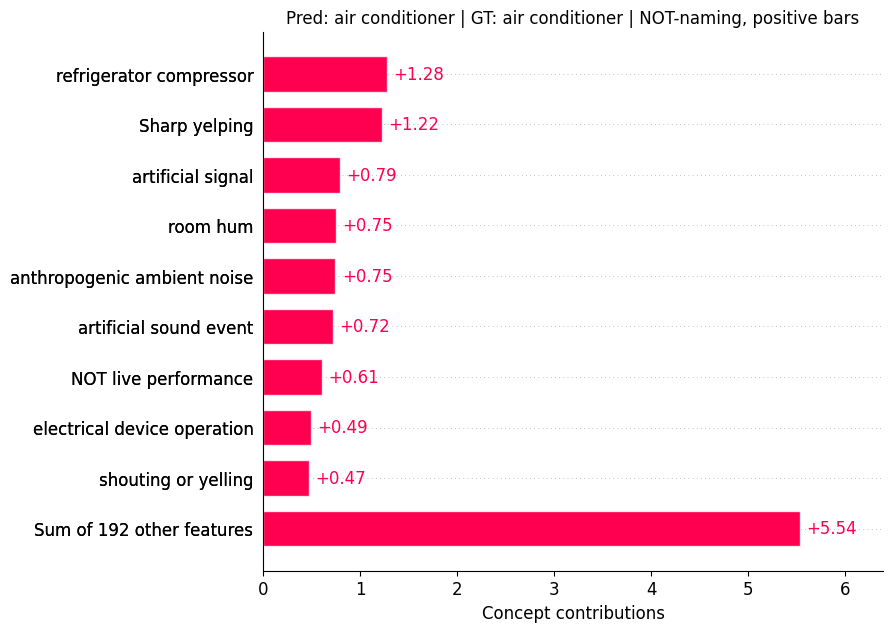

sample=38 | gt=engine_idling | pred=engine_idling | conf=0.997
path: data/urbansound8k/raw/fold10/102857-5-0-26.wav


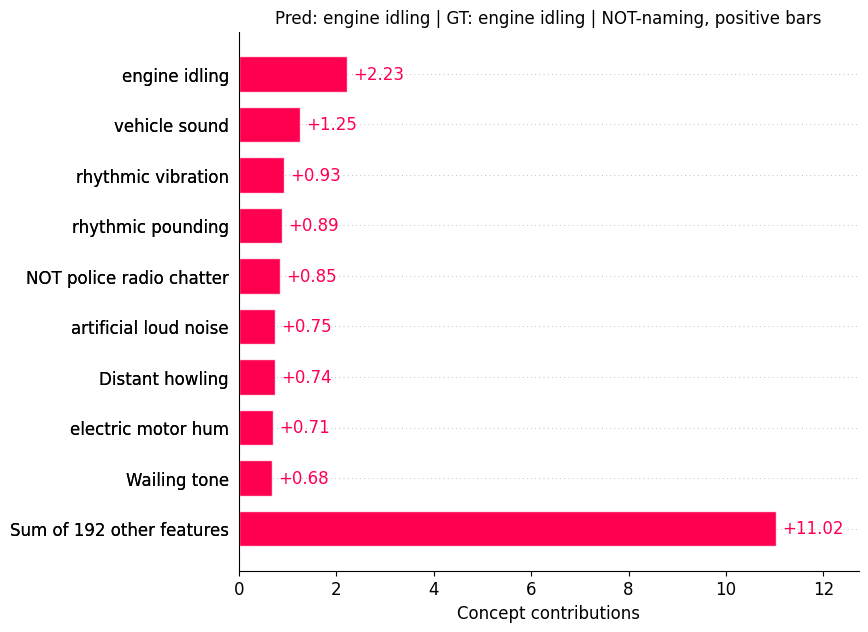

sample=423 | gt=drilling | pred=drilling | conf=0.830
path: data/urbansound8k/raw/fold10/181624-4-5-0.wav


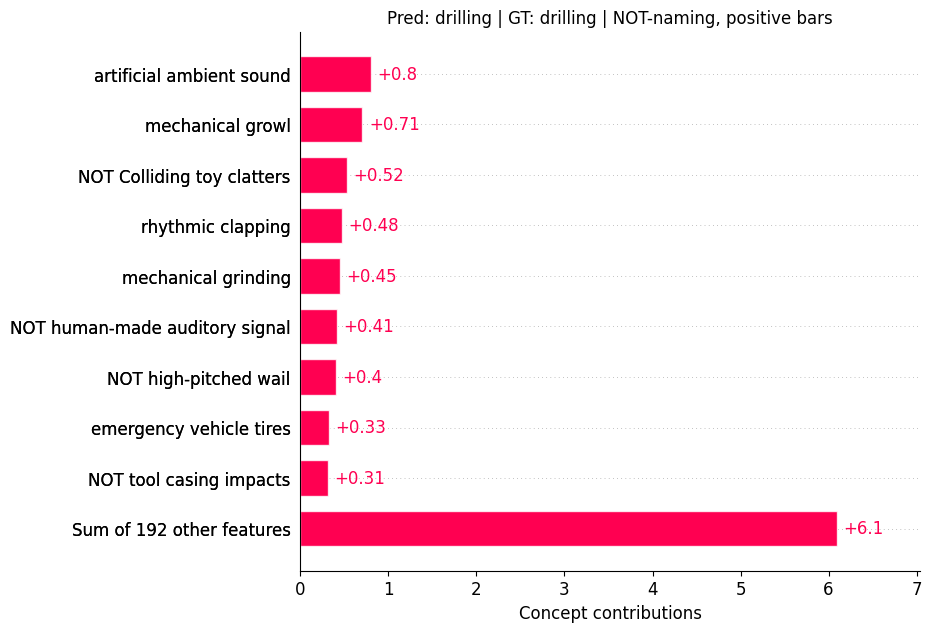


audio explanations for similar set: jackhammer (0.99), drilling (0.81)
sample=462 | gt=jackhammer | pred=jackhammer | conf=0.543
path: data/urbansound8k/raw/fold10/188813-7-4-0.wav


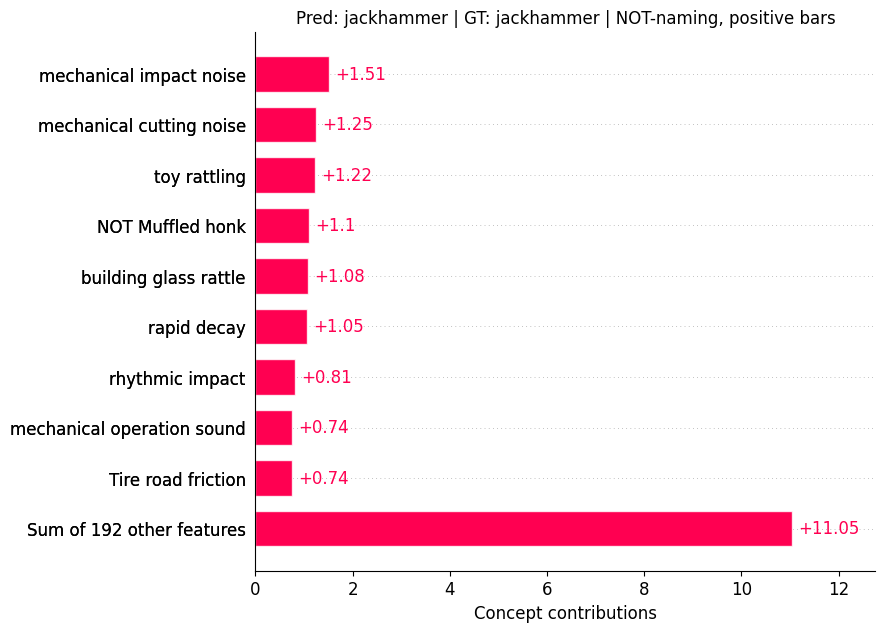

sample=85 | gt=drilling | pred=drilling | conf=0.666
path: data/urbansound8k/raw/fold10/118278-4-0-2.wav


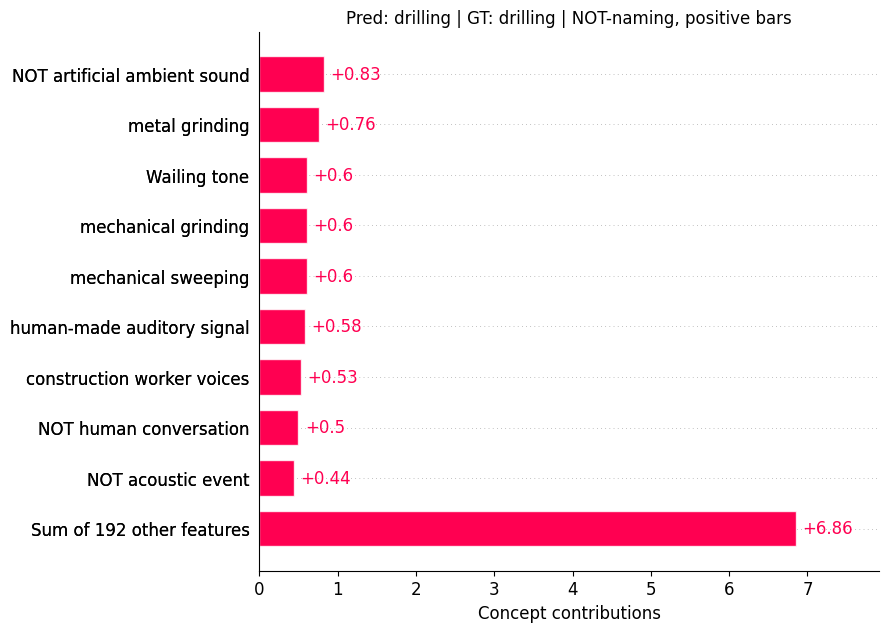


audio explanations for similar set: siren (0.77), car horn (0.97), gun shot (0.97)
sample=221 | gt=siren | pred=siren | conf=0.999
path: data/urbansound8k/raw/fold10/159742-8-0-4.wav


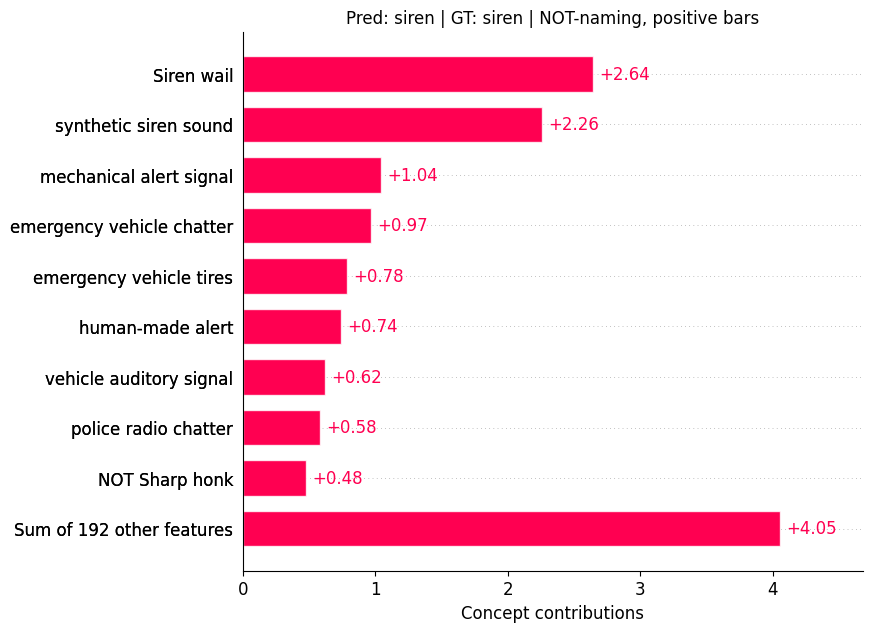

sample=349 | gt=car_horn | pred=car_horn | conf=0.996
path: data/urbansound8k/raw/fold10/17124-1-0-0.wav


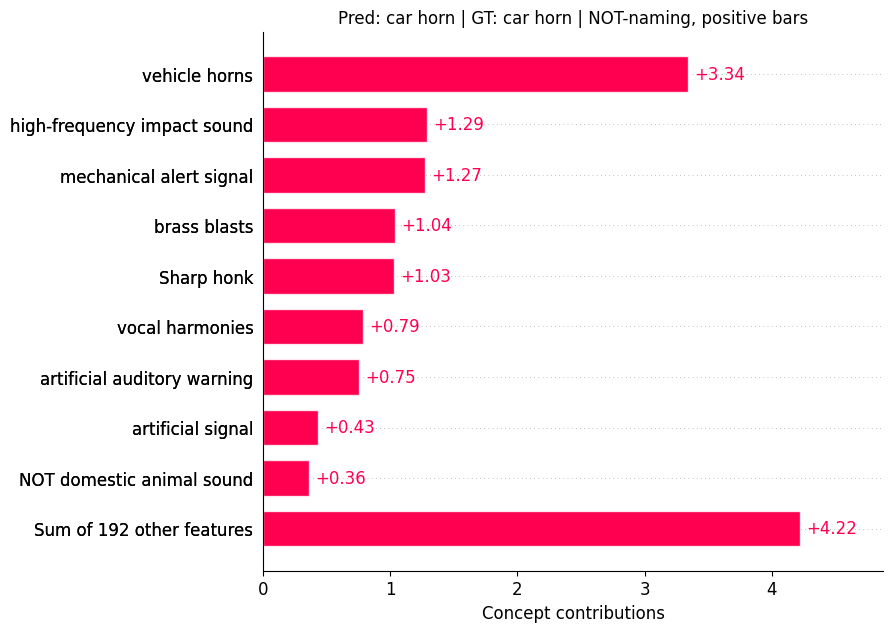

sample=524 | gt=gun_shot | pred=gun_shot | conf=0.989
path: data/urbansound8k/raw/fold10/200460-6-1-0.wav


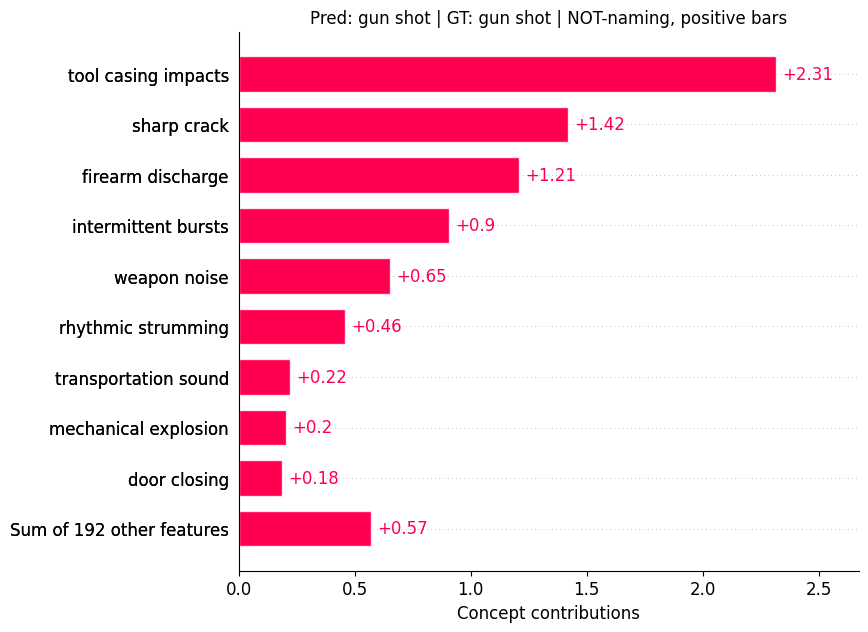

In [7]:
def _pretty(name):
    return name.replace("_", " ")

def build_class_index(dataset):
    out = {}
    for i, sample in enumerate(dataset.samples):
        cls_idx = int(sample["label_idx"])
        out.setdefault(cls_idx, []).append(i)
    return out

indices_by_class_idx = build_class_index(eval_dataset)

CLASS_ACC_HINT = {
    "air_conditioner": 0.80,
    "engine_idling": 0.87,
    "drilling": 0.81,
    "jackhammer": 0.99,
    "siren": 0.77,
    "car_horn": 0.97,
    "gun_shot": 0.97,
}

SIMILAR_CLASS_SETS = [
    ["air_conditioner", "engine_idling", "drilling"],
    ["jackhammer", "drilling"],
    ["siren", "car_horn", "gun_shot"],
]

# true: use NOT concept names and force positive bars
USE_NOT_FEATURE_NAMING = True

for group in SIMILAR_CLASS_SETS:
    missing = [c for c in group if c not in class_to_idx]
    if missing:
        raise ValueError(f"Missing classes in UrbanSound8K labels: {missing}")

def _format_group(group):
    return ", ".join([f"{_pretty(c)} ({CLASS_ACC_HINT.get(c, 0.0):.2f})" for c in group])

def show_audio_explanation(sample_idx, max_concepts=10):
    sample = eval_dataset[sample_idx]
    audio = sample["audio"]
    sr = int(sample["sr"])
    gt_idx = int(sample["target"])


    with torch.no_grad():
        logits, concept_act = model(audio.unsqueeze(0).to(device))


    logits = logits[0].detach().cpu()
    concept_act = concept_act[0].detach().cpu()
    probs = torch.softmax(logits, dim=0)
    pred_idx = int(torch.argmax(probs).item())


    print(f"sample={sample_idx} | gt={idx_to_class[gt_idx]} | pred={idx_to_class[pred_idx]} | conf={probs[pred_idx]:.3f}")
    print(f"path: {sample['path']}")
    display(Audio(audio.squeeze(0).cpu().numpy(), rate=sr))


    raw_contrib = (concept_act * model.final.weight[pred_idx].detach().cpu()).numpy()


    if USE_NOT_FEATURE_NAMING:
        contrib = np.abs(raw_contrib)
        feature_names = [
            (concepts[i] if raw_contrib[i] >= 0 else f"NOT {concepts[i]}")
            for i in range(len(concepts))
        ]
        mode_tag = "NOT-naming, positive bars"
    else:
        contrib = raw_contrib.copy()
        feature_names = [concepts[i] for i in range(len(concepts))]
        mode_tag = "signed bars (top by absolute contribution)"


    title = f"Pred: {_pretty(idx_to_class[pred_idx])} | GT: {_pretty(idx_to_class[gt_idx])} | {mode_tag}"
    plots.bar(contrib.copy(), feature_names, max_display=max_concepts, title=title, fontsize=12)


rng = random.Random(7)
for group in SIMILAR_CLASS_SETS:
    print("\n" + "=" * 100)
    print("audio explanations for similar set:", _format_group(group))
    print("=" * 100)
    for class_name in group:
        cls_idx = class_to_idx[class_name]
        pool = indices_by_class_idx.get(cls_idx, [])
        if len(pool) == 0:
            print(f"No samples found for class {class_name}")
            continue
        sample_idx = rng.choice(pool)
        show_audio_explanation(sample_idx=sample_idx, max_concepts=10)

## Figure 3-style final-layer weight visualizations
Each figure shows concept-to-class links for one selected UrbanSound8K similar-class set, using signed final-layer weights from the trained UrbanSound8K CBM.

In [8]:
def make_group_sankey(group_classes, top_k=5, min_abs_weight=0.03):
    if not HAS_PLOTLY:
        raise ImportError("Plotly is required for Sankey rendering. Install with: pip install plotly")

    class_ids = [class_to_idx[c] for c in group_classes]
    final_w = model.final.weight.detach().cpu().numpy()

    links = []
    for class_name, cls_id in zip(group_classes, class_ids):
        w = final_w[cls_id]
        ranked = np.argsort(np.abs(w))[::-1]
        selected = [i for i in ranked if abs(w[i]) >= min_abs_weight][:top_k]
        if len(selected) == 0:
            selected = ranked[:top_k]
        for concept_idx in selected:
            links.append((concept_idx, class_name, float(w[concept_idx])))

    unique_concepts = sorted({cidx for cidx, _, _ in links})
    concept_node = {cidx: i for i, cidx in enumerate(unique_concepts)}
    class_node = {name: len(unique_concepts) + i for i, name in enumerate(group_classes)}

    node_labels = [concepts[cidx] for cidx in unique_concepts] + [_pretty(name) for name in group_classes]
    node_colors = ["rgba(120,120,120,0.6)" for _ in unique_concepts] + [
        "rgba(217,95,2,0.8)",
        "rgba(27,158,119,0.8)",
        "rgba(117,112,179,0.8)",
        "rgba(231,41,138,0.8)",
        "rgba(102,166,30,0.8)",
    ][:len(group_classes)]

    sources = []
    targets = []
    values = []
    colors = []
    hover = []

    for cidx, cname, weight in links:
        sources.append(concept_node[cidx])
        targets.append(class_node[cname])
        values.append(abs(weight))
        colors.append("rgba(214,39,40,0.45)" if weight >= 0 else "rgba(31,119,180,0.45)")
        hover.append(f"{concepts[cidx]} -> {_pretty(cname)}<br>weight={weight:+.4f}")

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=16,
                    thickness=14,
                    line=dict(color="rgba(40,40,40,0.25)", width=0.5),
                    label=node_labels,
                    color=node_colors,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color=colors,
                    customdata=hover,
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ]
    )
    fig.update_layout(
        title=f"UrbanSound8K CBM | Figure 3 style | {' vs '.join([_pretty(c) for c in group_classes])}",
        width=1300,
        height=max(520, 140 * len(group_classes)),
        font=dict(size=13),
    )
    fig.show()

for group in SIMILAR_CLASS_SETS:
    make_group_sankey(group_classes=group, top_k=4, min_abs_weight=0.03)